### SHAP Setup Stable 70%

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap


def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=10,
    shap_background_size=100,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features
      - shap_stack
      - X_stack
      - exp_vals_per_fold
      - signed_mean_shaps
      - abs_mean_shaps
      - last_model
      - last_test_len
      - last_exp_val
    """
    df = pd.read_excel(data_path)
    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column])
    features = X.columns.tolist()

    cv = RepeatedStratifiedKFold(
        n_splits=cv_splits,
        n_repeats=cv_repeats,
        random_state=42
    )

    all_shap = []
    all_X = []
    exp_vals_per_fold = []

    last_model = None
    last_test_len = None
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        dummy_col = "Geschlecht_weiblich"
        cols_to_scale = [c for c in X_train.columns if c != dummy_col]

        X_train_s = X_train.copy()
        X_test_s = X_test.copy()

        scaler = StandardScaler()
        X_train_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        X_train_s = X_train_s.values
        X_test_s = X_test_s.values

        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            C=0.842,
            class_weight=None,
            random_state=42
        )
        lr.fit(X_train_s, y_train)

        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr,
            bg,
            feature_names=features,
            model_output="log_odds"
        )

        sv = expl(X_test_s)
        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)

        all_shap.append(vals)
        all_X.append(X_test_s)

        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            exp_val = float(exp_raw)

        exp_vals_per_fold.append(exp_val)

        # Für Selbsttest: letzten Fold merken
        last_model = lr
        last_test_len = len(X_test_s)
        last_exp_val = exp_val

    shap_stack = np.vstack(all_shap)
    X_stack = np.vstack(all_X)

    signed_mean_shaps = np.nanmean(shap_stack, axis=0)
    abs_mean_shaps = np.nanmean(np.abs(shap_stack), axis=0)

    return (
        features,
        shap_stack,
        X_stack,
        exp_vals_per_fold,
        signed_mean_shaps,
        abs_mean_shaps,
        last_model,
        last_test_len,
        last_exp_val
    )


features, shap_stack, X_stack, exp_vals_per_fold, signed_mean_shaps, abs_mean_shaps, last_model, last_test_len, last_exp_val = collect_shap_data_lr(
    data_path=r"K:\Team\Böhmer_Michael\PAPER\Philipp\Datensatz\ML_Datasets\dataset_stable70.xlsx",
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=10,
    shap_background_size=100,
    verbose=False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", np.min(shap_stack),
      "Max:", np.max(shap_stack),
      "Mean:", np.mean(shap_stack))
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(),
      "Inf:", np.isinf(shap_stack).sum())

print("\nExpected Value (log-odds):")
print("→ Mittelwert über Folds:", np.mean(exp_vals_per_fold))
print("→ Std über Folds:", np.std(exp_vals_per_fold))

print("\nSelbsttest-Infos (letzter Fold):")
print("→ last_test_len:", last_test_len)
print("→ last_exp_val:", last_exp_val)
print("→ X_stack shape:", X_stack.shape)
print("→ shap_stack shape:", shap_stack.shape)

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]

print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")


SHAP-Wertprüfung:
→ Min: -4.530248479826868 Max: 4.157934246971635 Mean: -0.00494386826567074
→ Anzahl NaN: 0 Inf: 0

Expected Value (log-odds):
→ Mittelwert über Folds: -0.014094729086222993
→ Std über Folds: 0.08906909123890044

Selbsttest-Infos (letzter Fold):
→ last_test_len: 16
→ last_exp_val: 0.08822475309360711
→ X_stack shape: (830, 15)
→ shap_stack shape: (830, 15)

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_CMJ_uni_Peak braking force                                     +0.012544        1.314807
UNINV_CMJ_uni_Av. propulsive force                                 +0.001803        1.034452
INV_Arbeit_Flexion                                                 -0.001305        0.850963
UNINV_CMJ_uni_Peak Landing Force-Mittelwert                        +0.002247        0.544977
INV_ISO_Drehmoment_

### SHAP Test

In [7]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap = []
p_from_model = []

for i in idx_local:
    logit_i = last_exp_val + shap_stack[i].sum()
    p_from_shap.append(expit(logit_i))
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model

print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")


=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 1.110e-16
Mittlere Abweichung : 2.359e-17
Median Abweichung   : 0.000e+00

P_SHAP=0.008043 | P_Modell=0.008043 | Δ=+6.94e-18
P_SHAP=0.347454 | P_Modell=0.347454 | Δ=+1.11e-16
P_SHAP=0.243690 | P_Modell=0.243690 | Δ=+0.00e+00
P_SHAP=0.995274 | P_Modell=0.995274 | Δ=+0.00e+00
P_SHAP=0.121004 | P_Modell=0.121004 | Δ=+0.00e+00


### Globale SHAP Log odds

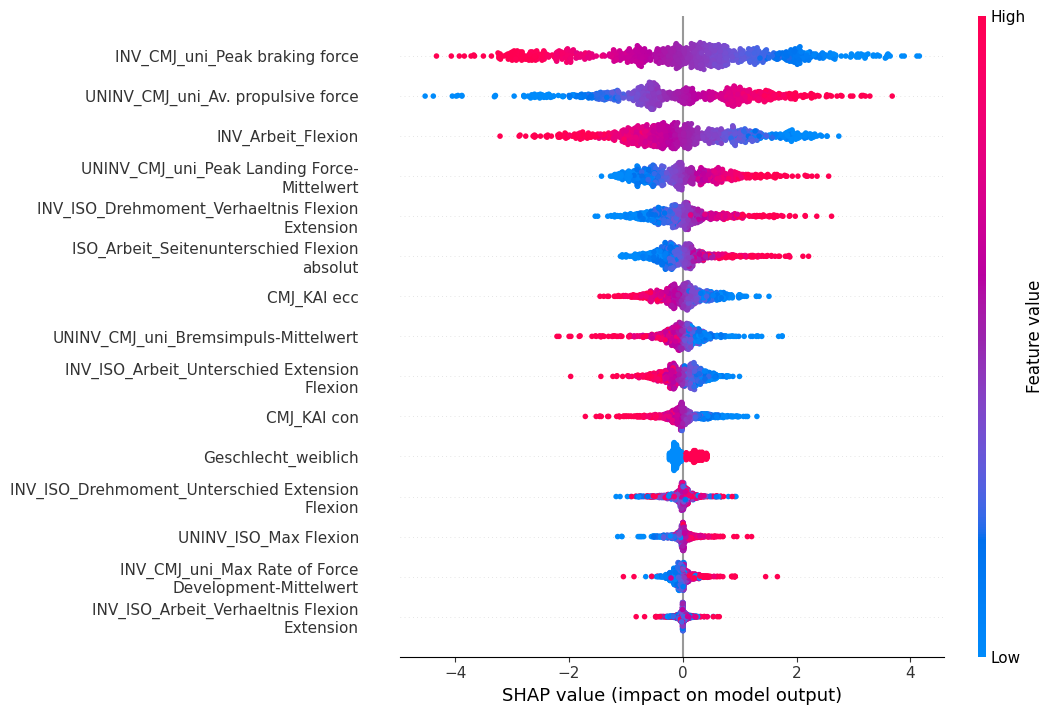

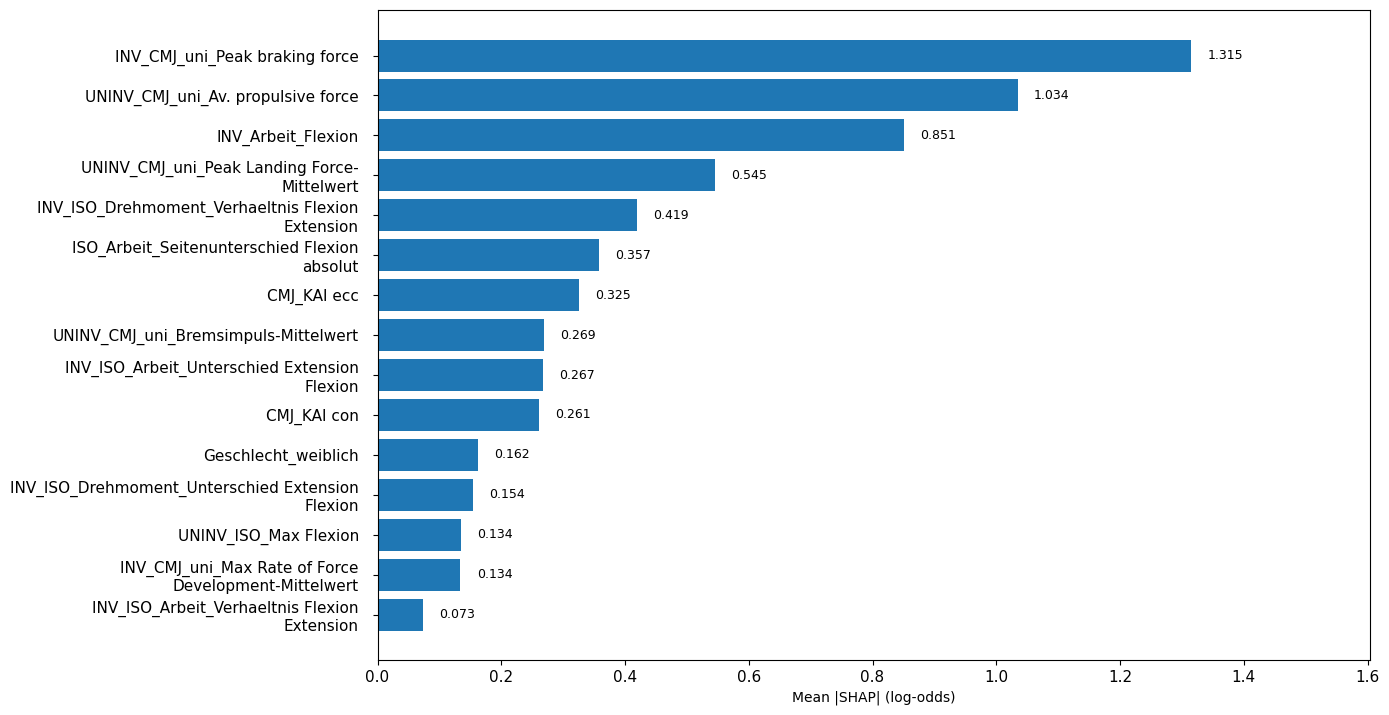

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend                             
order_bee = order_bar                                      # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()


